#  1:  End-to-End Sales Forecasting & Demand Intelligence System

## Objective

The goal of this project is to forecast future sales demand using
three different forecasting approaches:

1. SARIMA - Statistical Time Series Model
2. Prophet - Industry Forecasting Model
3. XGBoost - Machine Learning Based Forecasting

The best performing model will be deployed using Streamlit. 

In [1]:
import pandas as pd
import numpy as np


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Time series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller


# Models
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor


# Evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error


# Save model
import pickle

import warnings
warnings.filterwarnings("ignore")

# 2. Load Dataset

In [2]:
df = pd.read_csv("train.csv")

df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


###  Dataset Description

The dataset contains historical retail transactions including:

- Order information
- Customer information
- Product categories
- Regions
- Sales values

For forecasting, transaction-level data will be aggregated into monthly sales.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [4]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [5]:
# Understand Data
df.shape

(9800, 18)

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

# 3. Convert Dates

In [7]:

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)


df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True
)

### Why convert dates?

Time series models require chronological ordering.
The Order Date column is converted into datetime format
to extract yearly, monthly, and seasonal patterns.

In [8]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

In [9]:
df.duplicated().sum()

0

### Duplicate Check

Duplicate records are checked because duplicate transactions
can artificially increase sales values and affect forecasting accuracy.

# 4.Missing Values

In [10]:
# Check missing values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

### Missing Value Treatment

Postal Code is a location identifier.
Since it is not used as a forecasting feature,
missing values are replaced with the median value to preserve the dataset.

In [11]:
# Remove unnecessary missing postal code:
df["Postal Code"].fillna(
    df["Postal Code"].median(),
    inplace=True
)

# 5. Feature Engineering

In [12]:
df["Year"] = df["Order Date"].dt.year


df["Month"] = df["Order Date"].dt.month


df["Month_Name"] = (
    df["Order Date"]
    .dt.month_name()
)


df["Week"] = (
    df["Order Date"]
    .dt.isocalendar()
    .week
)


df["Day"] = (
    df["Order Date"]
    .dt.day_name()
)


df["Quarter"] = (
    df["Order Date"]
    .dt.quarter
)

df["Shipping_Days"] = (
    df["Ship Date"] -
    df["Order Date"]
).dt.days

In [13]:
df[["Order Date",
    "Ship Date",
    "Shipping_Days"]].head()

,Order Date,Ship Date,Shipping_Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [14]:
category_sales = (
    df.groupby("Category")
    ["Sales"]
    .sum()
    .sort_values(
        ascending=False
    )
)


category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

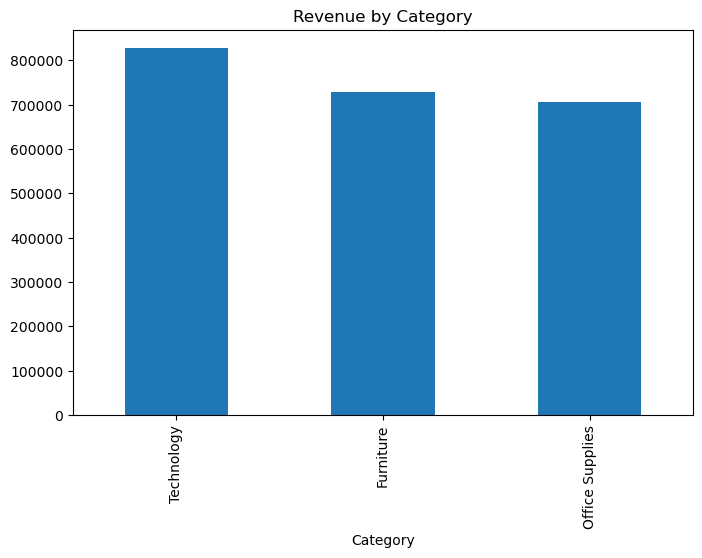

In [15]:
category_sales.plot(
    kind="bar",
    figsize=(8,5),
    title="Revenue by Category"
)
plt.savefig("charts/Revenue by Category.png")
plt.show()

### Observation

The category with the highest total sales represents the largest revenue contributor.
This information can help businesses prioritize inventory and marketing decisions.

In [16]:
region_year_sales = (
    df.groupby(
        [
            "Region",
            "Year"
        ]
    )
    ["Sales"]
    .sum()
    .reset_index()
)


region_year_sales

,Region,Year,Sales
0,Central,2015,102920.5206
1,Central,2016,102425.1724
2,Central,2017,145673.8800
3,Central,2018,141627.3402
4,East,2015,127652.8190
5,East,2016,153225.1830
6,East,2017,178511.5380
7,East,2018,210129.1860
8,South,2015,103374.9055
9,South,2016,70076.0825


In [17]:
region_growth = (
    region_year_sales
    .groupby("Region")
    ["Sales"]
    .pct_change()
)


region_growth

0          NaN
1    -0.004813
2     0.422247
3    -0.027778
4          NaN
5     0.200327
6     0.165027
7     0.177118
8          NaN
9    -0.322117
10    0.334776
11    0.306071
12         NaN
13   -0.083603
14    0.364683
15    0.359836
Name: Sales, dtype: float64

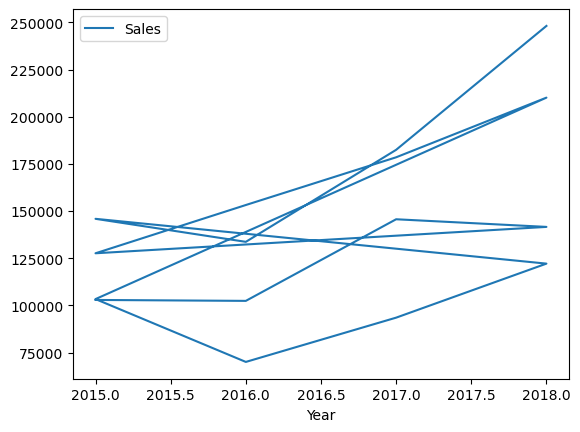

In [18]:
region_year_sales.plot(
    x="Year",
    y="Sales",
    kind="line"
)
plt.savefig("charts/line.png")
plt.show()

### Observation

Regions with stable yearly sales growth indicate consistent demand,
while large fluctuations may indicate seasonal or market changes.

# Average Shipping Time by Region

In [19]:
shipping_region = (
    df.groupby("Region")
    ["Shipping_Days"]
    .mean()
    .sort_values()
)


shipping_region

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping_Days, dtype: float64

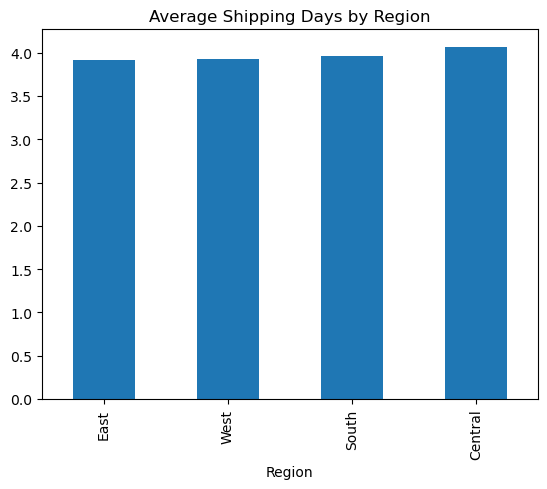

In [20]:
shipping_region.plot(
    kind="bar",
    title="Average Shipping Days by Region"
)
plt.savefig("charts/Average Shipping Days by Region.png")
plt.show()

# Seasonal Months

In [21]:
seasonal_sales = (
    df.groupby("Month")
    ["Sales"]
    .sum()
)


seasonal_sales

Month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64

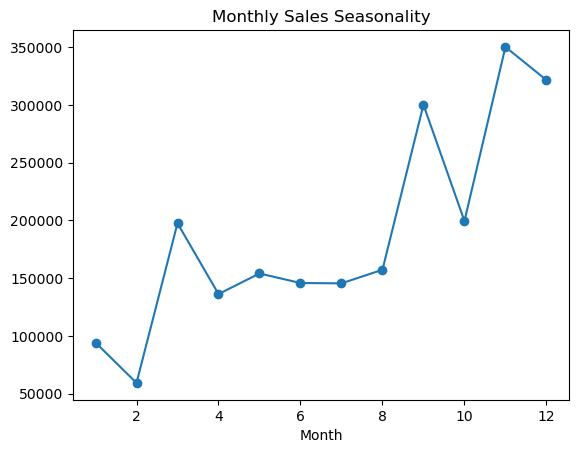

In [22]:
seasonal_sales.plot(
    kind="line",
    marker="o",
    title="Monthly Sales Seasonality"
)
plt.savefig("charts/Monthly Sales Seasonality.png")
plt.show()

# Weekly Aggregation Missing

In [23]:
weekly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )
    ["Sales"]
    .sum()
    .reset_index()
)


weekly_sales.columns=[
    "Date",
    "Sales"
]


weekly_sales.head()

,Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [24]:
def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Fall"



df["Season"] = df["Month"].apply(get_season)

# 6. Create Time Series Dataset

In [25]:
monthly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="M"
        )
    )
    ["Sales"]
    .sum()
)


monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

In [26]:
# Convert to DataFrame:
monthly_sales = monthly_sales.reset_index()


monthly_sales.columns=[
    "Date",
    "Sales"
]


monthly_sales.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


## Monthly Sales Aggregation

Forecasting models cannot directly work with transaction rows.
Therefore, daily transactions are aggregated into monthly sales totals.

Monthly aggregation helps capture:
- trend
- yearly seasonality
- demand patterns

# 7. Visualize Trend

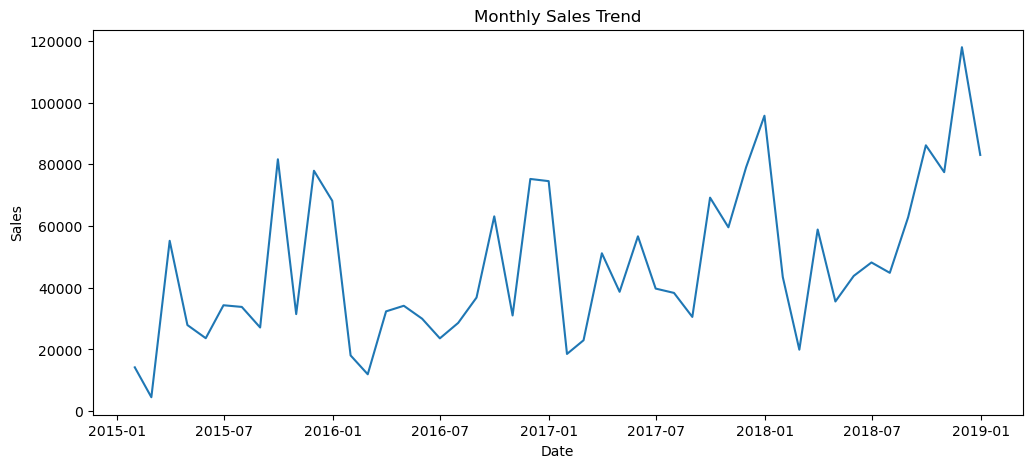

In [27]:
plt.figure(figsize=(12,5))


plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"]
)


plt.title(
    "Monthly Sales Trend"
)


plt.xlabel("Date")

plt.ylabel("Sales")

plt.savefig("charts/Visualize Trend.png")
plt.show()

# 8. Time Series Decomposition

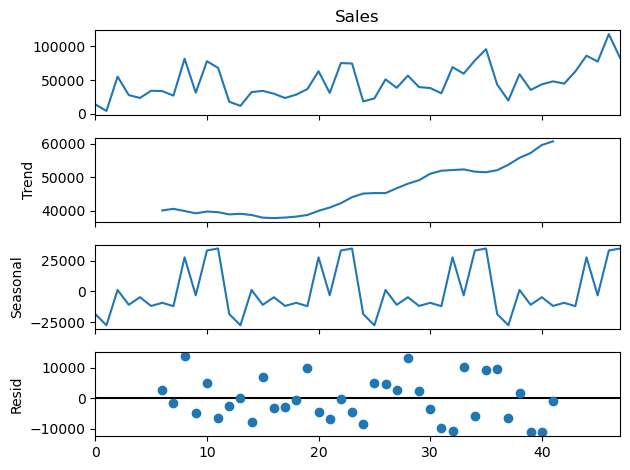

In [28]:
decomposition = seasonal_decompose(
    monthly_sales["Sales"],
    model="additive",
    period=12
)


decomposition.plot()

plt.savefig("charts/Time Series Decomposition.png")
plt.show()

## Decomposition Observations

1. Sales show an increasing trend over the four-year period.
2. Seasonal patterns exist because some months repeatedly generate higher sales.
3. Residual components represent unexpected demand changes.
4. Higher residual values indicate unusual sales behavior.

# 9. Stationarity Test

In [29]:
result = adfuller(
    monthly_sales["Sales"]
)


print(
"ADF Statistic:",
result[0]
)


print(
"P-value:",
result[1]
)

ADF Statistic: -4.416136761430769
P-value: 0.00027791039276670623


## ADF Test Interpretation

The Augmented Dickey-Fuller test checks whether the time series
has a constant statistical behavior over time.

If:

p-value <= 0.05:
The series is stationary.

p-value > 0.05:
The series is non-stationary and differencing may be required.

# 10. Train/Test Split

In [30]:
train = monthly_sales.iloc[:-3]


test = monthly_sales.iloc[-3:]

In [31]:
print(train.shape)
print(test.shape)

(45, 2)
(3, 2)


## SARIMA Parameter Selection

The model uses:

(p,d,q) = (1,1,1)

- p=1: uses previous observation
- d=1: first differencing to remove trend
- q=1: uses previous forecasting errors

Seasonal parameters:

(P,D,Q,m)=(1,1,1,12)

because monthly sales usually have yearly seasonality.

# MODEL 1 — SARIMAX

In [32]:
sarima_model = SARIMAX(
    train["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)


sarima_result = sarima_model.fit()

In [33]:
# checking summary
print(
    sarima_result.summary()
)

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -347.979
Date:                            Tue, 07 Jul 2026   AIC                            705.958
Time:                                    21:43:42   BIC                            713.287
Sample:                                         0   HQIC                           708.387
                                             - 45                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5680      0.242      2.347      0.019       0.094       1.042
ma.L1         -0.8985      0.177   

# Forecast Next 3 Months

In [34]:
sarima_forecast = sarima_result.forecast(
    steps=3
)


sarima_forecast

45    66177.602384
46    92049.249653
47    99965.168685
Name: predicted_mean, dtype: float64

# Plot SARIMA Forecast

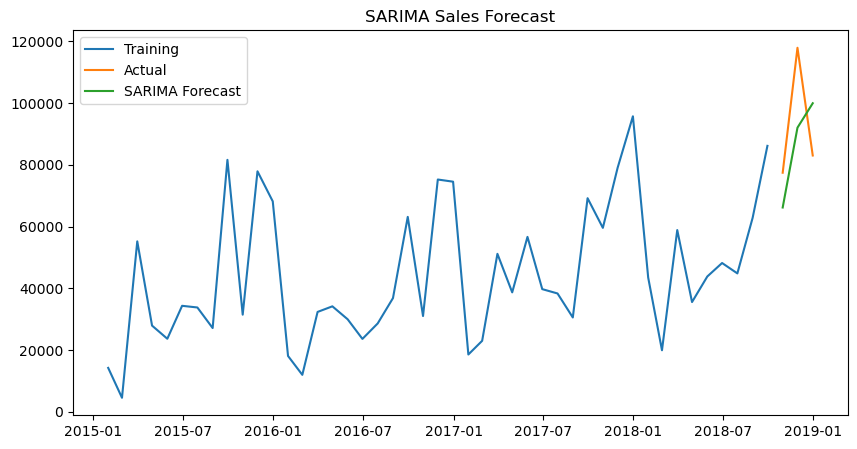

In [35]:
plt.figure(figsize=(10,5))


plt.plot(
    train["Date"],
    train["Sales"],
    label="Training"
)


plt.plot(
    test["Date"],
    test["Sales"],
    label="Actual"
)


plt.plot(
    test["Date"],
    sarima_forecast,
    label="SARIMA Forecast"
)


plt.legend()

plt.title(
    "SARIMA Sales Forecast"
)

plt.savefig("charts/Plot SARIMA Forecast.png")

plt.show()

# MODEL 2 — PROPHET

In [36]:
prophet_data = monthly_sales.copy()


prophet_data.columns=[
    "ds",
    "y"
]


prophet_train = prophet_data.iloc[:-3]

# Train Prophet

In [37]:
from prophet import Prophet


prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)


prophet_model.fit(
    prophet_train
)

21:43:44 - cmdstanpy - INFO - Chain [1] start processing
21:43:46 - cmdstanpy - INFO - Chain [1] done processing


# Create Future Dates

In [38]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="M"
)


future.tail()

,ds
43,2018-08-31
44,2018-09-30
45,2018-10-31
46,2018-11-30
47,2018-12-31


# Forecast

In [39]:
prophet_prediction = prophet_model.predict(
    future
)


prophet_prediction[
    ["ds","yhat"]
].tail()

,ds,yhat
43,2018-08-31,47271.558236
44,2018-09-30,86613.953316
45,2018-10-31,51318.943858
46,2018-11-30,90325.654784
47,2018-12-31,90041.084479


In [40]:
# Get only future 3 months:
prophet_forecast = (
    prophet_prediction["yhat"]
    .tail(3)
)


prophet_forecast

45    51318.943858
46    90325.654784
47    90041.084479
Name: yhat, dtype: float64

# Prophet Plot

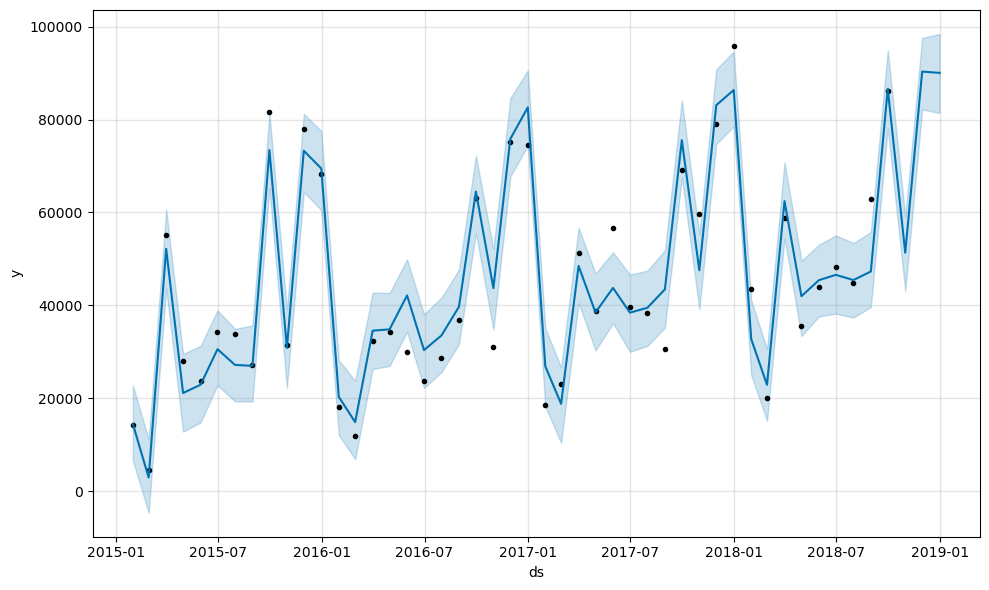

In [41]:
prophet_model.plot(
    prophet_prediction
)

plt.savefig("charts/Prophet Plot.png")

plt.show()

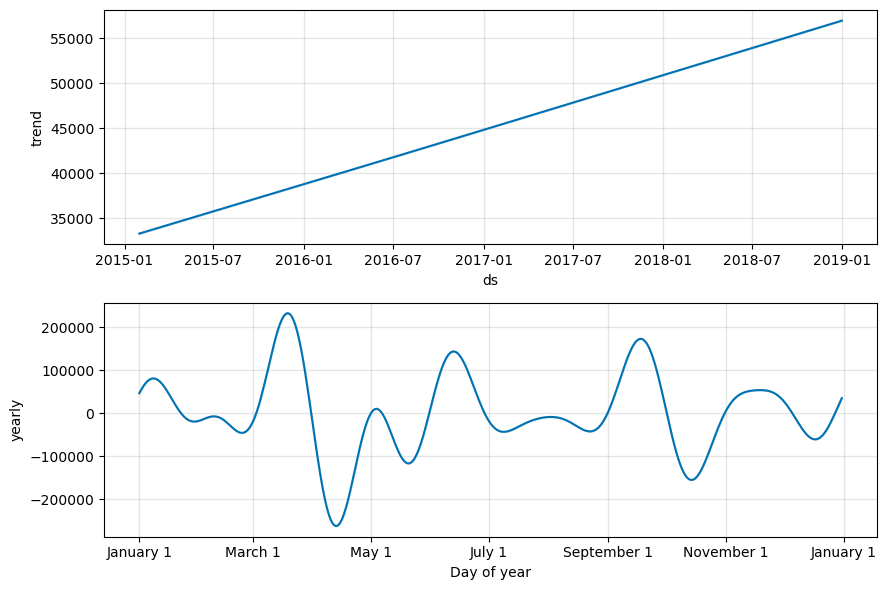

In [42]:
# Seasonality:
prophet_model.plot_components(
    prophet_prediction
)
plt.savefig("charts/Prophet Seasonality.png")
plt.show()

## Prophet Seasonality Observation

The yearly component shows which months have higher demand.
The trend component shows long-term sales movement.

# MODEL 3 — XGBoost Time Series

# Create Lag Features

In [43]:
xgb_data = monthly_sales.copy()


xgb_data["lag1"] = (
    xgb_data["Sales"]
    .shift(1)
)


xgb_data["lag2"] = (
    xgb_data["Sales"]
    .shift(2)
)


xgb_data["lag3"] = (
    xgb_data["Sales"]
    .shift(3)
)


xgb_data["rolling_mean"] = (
    xgb_data["Sales"]
    .rolling(3)
    .mean()
)


xgb_data["Month"] = (
    xgb_data["Date"]
    .dt.month
)


xgb_data["Quarter"] = (
    xgb_data["Date"]
    .dt.quarter
)


xgb_data.dropna(
    inplace=True
)


xgb_data.head()

,Date,Sales,lag1,lag2,lag3,rolling_mean,Month,Quarter
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3


# Split X and y

In [44]:
X = xgb_data.drop(
    columns=[
        "Date",
        "Sales"
    ]
)


y = xgb_data["Sales"]

# Time split:

In [45]:
X_train = X.iloc[:-3]

X_test = X.iloc[-3:]


y_train = y.iloc[:-3]

y_test = y.iloc[-3:]

# train XGBoost

In [46]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)


xgb_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [47]:
# Predict
xgb_forecast = xgb_model.predict(
    X_test
)


xgb_forecast

array([86530.49 , 87955.14 , 88256.445], dtype=float32)

# Model Evaluation

In [48]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error


def evaluate(actual,pred):

    mae = mean_absolute_error(
        actual,
        pred
    )


    rmse = np.sqrt(
        mean_squared_error(
            actual,
            pred
        )
    )


    mape = np.mean(
        np.abs(
            (actual-pred)/actual
        )
    )*100


    return mae,rmse,mape

# Evaluate SARIMA:

In [49]:
sarima_scores = evaluate(
    test["Sales"],
    sarima_forecast
)

sarima_scores

(18031.404682589244, 19009.18207606513, 18.9664980786781)

# Evaluate Prophet:

In [50]:
prophet_scores = evaluate(
    test["Sales"],
    prophet_forecast
)

prophet_scores

(20250.794412605526, 22318.411332860545, 21.864628273960825)

# Evaluate XGBoost:

In [51]:
xgb_scores = evaluate(
    y_test,
    xgb_forecast
)

xgb_scores

(14763.810624999998, 18337.412565486276, 14.481277237255794)

# Comparison Table

In [52]:
comparison = pd.DataFrame({

"Model":[
"SARIMA",
"Prophet",
"XGBoost"
],

"MAE":[
sarima_scores[0],
prophet_scores[0],
xgb_scores[0]
],

"RMSE":[
sarima_scores[1],
prophet_scores[1],
xgb_scores[1]
],

"MAPE":[
sarima_scores[2],
prophet_scores[2],
xgb_scores[2]
],

"Month_1_Forecast":[
sarima_forecast.iloc[0],
prophet_forecast.iloc[0],
xgb_forecast[0]
],

"Month_2_Forecast":[
sarima_forecast.iloc[1],
prophet_forecast.iloc[1],
xgb_forecast[1]
],

"Month_3_Forecast":[
sarima_forecast.iloc[2],
prophet_forecast.iloc[2],
xgb_forecast[2]
]

})


comparison

,Model,MAE,RMSE,MAPE,Month_1_Forecast,Month_2_Forecast,Month_3_Forecast
0,SARIMA,18031.404683,19009.182076,18.966498,66177.602384,92049.249653,99965.168685
1,Prophet,20250.794413,22318.411333,21.864628,51318.943858,90325.654784,90041.084479
2,XGBoost,14763.810625,18337.412565,14.481277,86530.492188,87955.140625,88256.445312


## Final Model Selection

After comparing SARIMA, Prophet, and XGBoost models using MAE, RMSE,
and MAPE metrics, XGBoost was selected as the final production model.

XGBoost achieved:

- Lowest MAE (14763.81)
- Lowest RMSE (18337.41)
- Lowest MAPE (14.48%)

This indicates that XGBoost provides more accurate sales forecasts
compared with the statistical and Prophet-based approaches.

The reason for better performance is that XGBoost can learn complex
patterns from historical sales using lag features, rolling averages,
and time-based features such as month and quarter.

Therefore, the XGBoost forecasting model will be deployed in the
Streamlit dashboard for future sales prediction.

In [53]:
# Create models folder
import os

os.makedirs(
    "models",
    exist_ok=True
)

In [54]:
comparison.to_csv(
"models/model_comparison.csv",
index=False
)

# Save Best Model

In [55]:
# Save model
with open(
    "models/xgb_sales_forecasting_model.pkl",
    "wb"
) as file:

    pickle.dump(
        xgb_model,
        file
    )

In [56]:
# Check file exists
os.listdir("models")

['model_comparison.csv', 'xgb_sales_forecasting_model.pkl']

In [57]:
# Test loading the model
with open(
    "models/xgb_sales_forecasting_model.pkl",
    "rb"
) as file:

    loaded_model = pickle.load(file)

In [58]:
prediction = loaded_model.predict(
    X_test
)

prediction

array([86530.49 , 87955.14 , 88256.445], dtype=float32)

In [59]:
monthly_sales.to_csv(
"models/monthly_sales.csv",
index=False
)

In [60]:
import sys

# Import libraries
import sklearn
import statsmodels
import xgboost
import prophet
import matplotlib
import seaborn
import plotly
import joblib
import pandas
import numpy

In [61]:
def create_requirements_file():

    # Store package versions
    packages = {
        "pandas": pandas.__version__,
        "numpy": numpy.__version__,
        "scikit-learn": sklearn.__version__,
        "statsmodels": statsmodels.__version__,
        "xgboost": xgboost.__version__,
        "prophet": prophet.__version__,
        "matplotlib": matplotlib.__version__,
        "seaborn": seaborn.__version__,
        "plotly": plotly.__version__,
        "joblib": joblib.__version__
    }


    # Print versions
    print("Installed Package Versions")
    print("-"*40)

    for package, version in packages.items():
        print(f"{package}: {version}")


    # Create requirements.txt

    with open("requirements.txt", "w") as file:

        for package, version in packages.items():

            file.write(
                f"{package}=={version}\n"
            )


    print("\nrequirements.txt created successfully!")


# Run function
create_requirements_file()

Installed Package Versions
----------------------------------------
pandas: 2.2.2
numpy: 1.26.4
scikit-learn: 1.6.1
statsmodels: 0.14.2
xgboost: 3.0.5
prophet: 1.3.0
matplotlib: 3.9.2
seaborn: 0.13.2
plotly: 5.24.1
joblib: 1.4.2

requirements.txt created successfully!


# Product Category and Region Forecasting

In [62]:
def forecast_xgb(data, periods=3):

    # Copy data
    temp = data.copy()

    # Sort by date
    temp = temp.sort_values("Date")


    # Create lag features

    temp["lag1"] = temp["Sales"].shift(1)

    temp["lag2"] = temp["Sales"].shift(2)

    temp["lag3"] = temp["Sales"].shift(3)


    # Rolling mean

    temp["rolling_mean"] = (
        temp["Sales"]
        .rolling(3)
        .mean()
    )


    # Date features

    temp["Month"] = (
        temp["Date"]
        .dt.month
    )

    temp["Quarter"] = (
        temp["Date"]
        .dt.quarter
    )


    # Remove missing rows

    temp = temp.dropna()


    # Features

    X = temp[
        [
            "lag1",
            "lag2",
            "lag3",
            "rolling_mean",
            "Month",
            "Quarter"
        ]
    ]


    y = temp["Sales"]


    # Train model

    model = XGBRegressor(
        n_estimators=200,
        random_state=42
    )


    model.fit(
        X,
        y
    )


    # Future prediction

    future = []

    history = list(
        temp["Sales"]
    )


    last_date = (
        temp["Date"]
        .max()
    )


    for i in range(periods):

        lag1 = history[-1]

        lag2 = history[-2]

        lag3 = history[-3]


        rolling = np.mean(
            history[-3:]
        )


        next_date = (
            last_date
            +
            pd.DateOffset(months=1)
        )


        features = pd.DataFrame({

            "lag1":[lag1],

            "lag2":[lag2],

            "lag3":[lag3],

            "rolling_mean":[rolling],

            "Month":[
                next_date.month
            ],

            "Quarter":[
                next_date.quarter
            ]

        })


        prediction = model.predict(
            features
        )[0]


        future.append(
            {
            "Date":next_date,
            "Forecast":prediction
            }
        )


        history.append(
            prediction
        )


        last_date = next_date


    return pd.DataFrame(future)

### This function:

Takes monthly sales data
Creates lag features:

Example:

Jan Sales = 100

Feb uses Jan as lag1

Mar uses Feb as lag1
Trains XGBoost
Predicts next 3 months

# Prepare Category Data

In [63]:
category_monthly = (
    df.groupby(
        [
            pd.Grouper(
                key="Order Date",
                freq="MS"
            ),
            "Category"
        ]
    )["Sales"]
    .sum()
    .reset_index()
)


category_monthly.head()

,Order Date,Category,Sales
0,2015-01-01,Furniture,6217.277
1,2015-01-01,Office Supplies,4845.140
2,2015-01-01,Technology,3143.290
3,2015-02-01,Furniture,1839.658
4,2015-02-01,Office Supplies,1071.724


In [64]:
# Rename:
category_monthly.columns = [
    "Date",
    "Category",
    "Sales"
]

# Forecast Each Category

## Furniture

In [65]:
furniture = category_monthly[
    category_monthly["Category"]
    ==
    "Furniture"
]


furniture_forecast = forecast_xgb(
    furniture[["Date","Sales"]]
)


furniture_forecast

,Date,Forecast
0,2019-01-01,9312.590820
1,2019-02-01,4846.509277
2,2019-03-01,16421.205078


## Technology

In [66]:
technology = category_monthly[
    category_monthly["Category"]
    ==
    "Technology"
]


technology_forecast = forecast_xgb(
    technology[["Date","Sales"]]
)

## Office Supplies

In [67]:
office = category_monthly[
    category_monthly["Category"]
    ==
    "Office Supplies"
]


office_forecast = forecast_xgb(
    office[["Date","Sales"]]
)

## Plot Category Forecast

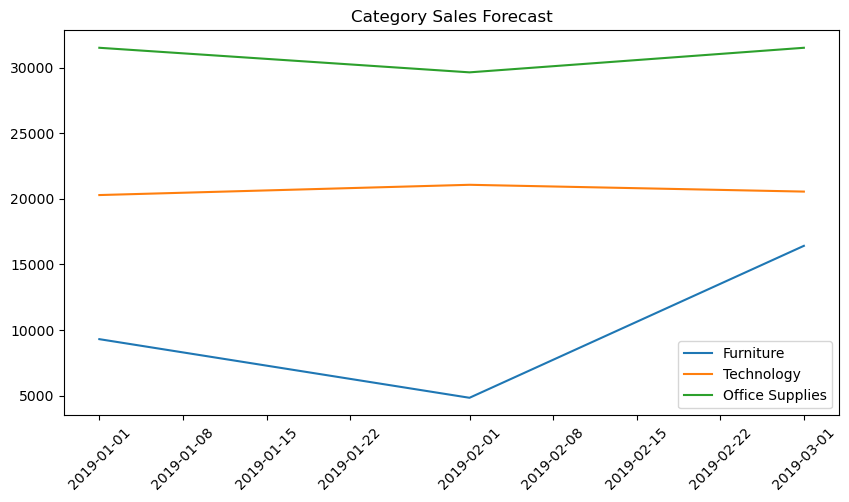

In [68]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))


plt.plot(
    furniture_forecast["Date"],
    furniture_forecast["Forecast"],
    label="Furniture"
)


plt.plot(
    technology_forecast["Date"],
    technology_forecast["Forecast"],
    label="Technology"
)


plt.plot(
    office_forecast["Date"],
    office_forecast["Forecast"],
    label="Office Supplies"
)


plt.title(
    "Category Sales Forecast"
)


plt.legend()

plt.xticks(rotation=45)
plt.savefig("charts/Category Sales Forecast.png")
plt.show()

## Region Forecast

In [69]:
region_monthly = (
    df.groupby(
        [
            pd.Grouper(
                key="Order Date",
                freq="MS"
            ),
            "Region"
        ]
    )["Sales"]
    .sum()
    .reset_index()
)


region_monthly.columns=[
    "Date",
    "Region",
    "Sales"
]

## West

In [70]:
west = region_monthly[
    region_monthly["Region"]
    ==
    "West"
]


west_forecast = forecast_xgb(
    west[["Date","Sales"]]
)

## East

In [71]:
east = region_monthly[
    region_monthly["Region"]
    ==
    "East"
]


east_forecast = forecast_xgb(
    east[["Date","Sales"]]
)

## Plot Region Forecast

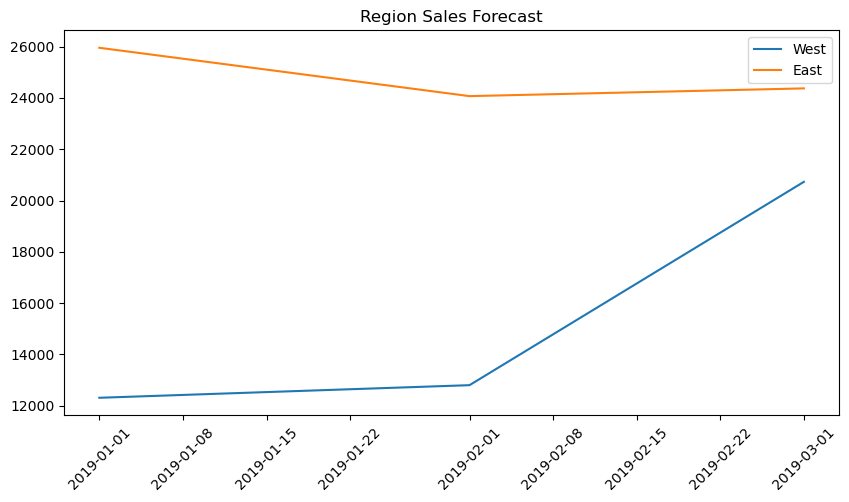

In [72]:
plt.figure(figsize=(10,5))


plt.plot(
    west_forecast["Date"],
    west_forecast["Forecast"],
    label="West"
)


plt.plot(
    east_forecast["Date"],
    east_forecast["Forecast"],
    label="East"
)


plt.title(
    "Region Sales Forecast"
)


plt.legend()

plt.xticks(rotation=45)

plt.savefig("charts/Region Sales Forecast.png")

plt.show()

# Save Results

In [73]:
furniture_forecast.to_csv(
    "models/furniture_forecast.csv",
    index=False
)


technology_forecast.to_csv(
    "models/technology_forecast.csv",
    index=False
)


office_forecast.to_csv(
    "models/office_forecast.csv",
    index=False
)


west_forecast.to_csv(
    "models/west_forecast.csv",
    index=False
)


east_forecast.to_csv(
    "models/east_forecast.csv",
    index=False
)

In [74]:
X = weekly_sales[
    ["Sales"]
]